In [2]:
"""
Feature Engineering

There are a lot of imports for this but we've seen a good chunk previously
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
# ColumnTransformer allows us to transform our columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

In [6]:
"""

Create a messy dataset

We want to practice working with a dataset that has numeric, categorical, missing
and outlier values, normally you'd grab a CSV and work with it like we're doing
here but building it ourselves gives us a little control
"""

def make_churn_data(n=900, random_state=42):
  # Set rng for generating distributions
  rng = np.random.default_rng(random_state)

  # Generate some columns using various distributions
  age = rng.normal(38, 12, n).round().clip(18,80)
  account_age_months = rng.gamma(4, 8, n).round().clip(1, 120)
  monthly_spend = rng.normal(75, 25, n).clip(10, 250)
  support_tickets = rng.poisson(1.6, n)
  days_since_login = rng.exponential(9, n).round().clip(0,90)
  has_discount = rng.choice(["yes", "no"], size = n, p=[.35, .65])
  contract_type = rng.choice(["month-to-month", "one-year", "two-year"], size = n, p=[.55, .3, .15])
  region = rng.choice(['Northeast', 'Southeast', 'Midwest', 'West'], size = n)

  # Build our Logit
  # Think of this as the linear regression before going into the sigmoid function
  logit = (
      -1.1
      + .035 * (monthly_spend - 75)
      + .32 * support_tickets
      + .04 * days_since_login
      -.018 * account_age_months
      + np.where(contract_type == "month-to-month", .9, 0)
      + np.where(contract_type == "two-year", -.7, 0)
      + np.where(has_discount == "yes", -.35, 0)
  )

  # Sigmoid
  prob = 1 / (1 + np.exp(-logit))
  churned = rng.binomial(1, prob)

  df = pd.DataFrame({
      "age": age,
      "account_age_months": account_age_months,
      "monthly_spend": monthly_spend.round(2),
      "support_tickets": support_tickets,
      "days_since_login": days_since_login,
      "has_discount": has_discount,
      "contract_type": contract_type,
      "region": region,
      "churned": churned
  })

  # Inject some missing values
  for col in ["age", "monthly_spend", "contract_type", "region"]:
    missing_idx = rng.choice(df.index, size=int(.06 * n), replace=False)
    df.loc[missing_idx, col] = np.nan

  # Inject some outliers
  outlier_idx = rng.choice(df.index, size = 8, replace=False)
  df.loc[outlier_idx, "monthly_spend"] = rng.choice([450, 500, 650], size = len(outlier_idx))

  return df

df = make_churn_data()
df.head()

,age,account_age_months,monthly_spend,support_tickets,days_since_login,has_discount,contract_type,region,churned
0,42.0,36.0,70.59,0,1.0,no,NaN,NaN,0
1,NaN,27.0,85.01,1,1.0,no,NaN,Northeast,0
2,47.0,21.0,10.00,2,10.0,no,one-year,NaN,0
3,49.0,26.0,82.56,1,5.0,yes,one-year,Northeast,0
4,18.0,30.0,72.17,0,5.0,no,month-to-month,Southeast,0


In [8]:
"""
Inspect our messy data
We want to see distributions, how many missing values, etc
This is a good first step when preprocessing data you've never seen before
"""

print(df.shape)
print("Distribution")
print(df["churned"].value_counts(normalize=True).round(3))

print("Missing Values")
print(df.isna().sum())

print("Numeric Summary")
df.describe()

(900, 9)
Distribution
churned
0    0.619
1    0.381
Name: proportion, dtype: float64
Missing Values
age                   54
account_age_months     0
monthly_spend         53
support_tickets        0
days_since_login       0
has_discount           0
contract_type         54
region                54
churned                0
dtype: int64
Numeric Summary


,age,account_age_months,monthly_spend,support_tickets,days_since_login,churned
count,846.000000,900.000000,847.000000,900.000000,900.000000,900.000000
mean,37.735225,31.891111,80.260295,1.513333,8.730000,0.381111
std,11.409572,15.972213,49.896246,1.226714,8.527609,0.485930
min,18.000000,3.000000,10.000000,0.000000,0.000000,0.000000
25%,29.250000,20.750000,59.025000,1.000000,3.000000,0.000000
50%,38.000000,30.000000,76.410000,1.000000,6.000000,0.000000
75%,45.000000,40.250000,93.745000,2.000000,12.000000,1.000000
max,76.000000,98.000000,650.000000,7.000000,51.000000,1.000000


In [11]:
"""
At this point we have identified there are some columns with missing values
Some columns with outliers
So what do we do?
"""

# Let's split our data to prevent any data leakage
X = df.drop(columns="churned")
y = df["churned"]

# It's also going to be useful to have our list of numeric versus categorical feature
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state = RANDOM_STATE,
    stratify=y
)

print(X_train.shape, X_test.shape)

(720, 8) (180, 8)


In [12]:
"""
This step here is finally our feature engineering
This is not a step we only do at the beginning we can loop back to this after
making an initial model but we have a couple of goals

Numeric -> Fill missing values with the median -> Scale
Categorical -> Fill missing values with the most frequent -> Encode categories
"""

# Pipelines will change the data as they pass through
numeric_pipeline = Pipeline(steps = [
    # Fill our missing values with the median, we use an Imputer
    ("imputer", SimpleImputer(strategy="median")),
    # Scale the values to help our models that struggle with scale
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps =[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # How do we encode our categories?
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer which will use the pipelines
preprocessor = ColumnTransformer(transformers = [
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [13]:
"""
We'll make 2 models
- Logistic Regression
- Random Forest (Collection of Decision Trees)
"""

# Logistic regression
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    # More not-churn -> Class has slightly less value
    # Less churned -> class has slightly larger value
])

rf_model=Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=8
    ))
])

log_reg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'account_age_months',
                                                   'monthly_spend',
                                                   'support_tickets',
                                                   'days_since_login']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['has_discount',
                                                   'contract_type',
                                                   'region'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        n_estimators=200, random_state=42))])

In [14]:
"""
Evaluation
Evaluation comes after training, we've seen this before where we look at various
metrics like accuracy, precision, recall f1-score, MSE, MAE

"""
print("Logistic Regression")
log_preds = log_reg_model.predict(X_test)
print(classification_report(y_test, log_preds, zero_division=0))

print("Random Forest")
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       111
           1       0.60      0.72      0.65        69

    accuracy                           0.71       180
   macro avg       0.70      0.71      0.70       180
weighted avg       0.72      0.71      0.71       180

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       111
           1       0.65      0.58      0.61        69

    accuracy                           0.72       180
   macro avg       0.70      0.69      0.69       180
weighted avg       0.71      0.72      0.71       180



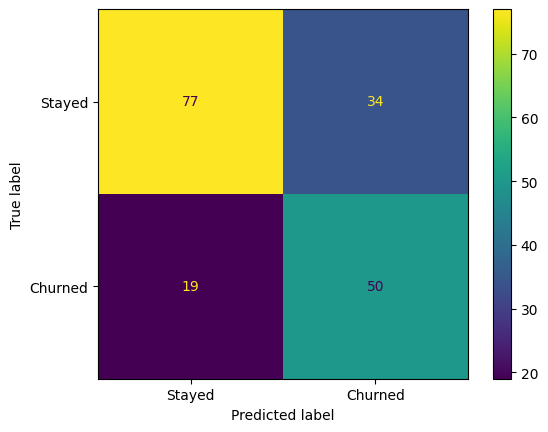

In [16]:
log_cm = confusion_matrix(y_test, log_preds)
disp = ConfusionMatrixDisplay(log_cm, display_labels=["Stayed", "Churned"])
disp.plot()
plt.show()

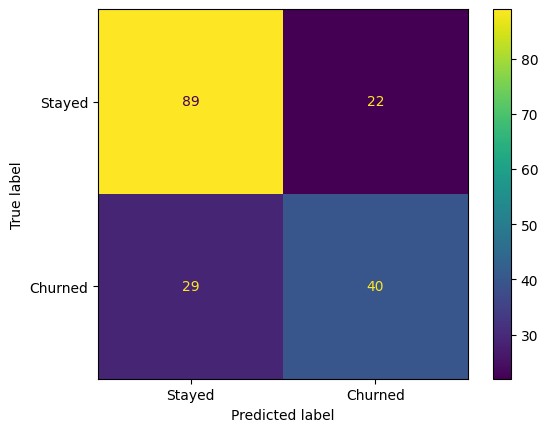

In [17]:
rf_cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(rf_cm, display_labels=["Stayed", "Churned"])
disp.plot()
plt.show()

In [19]:
"""
Cross Validation

So we haven't done this before but it will allow us to see how our model preforms with
different validation splits
"""

models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    print(name)
    print("F1 scores:", np.round(scores, 3))
    print("Mean F1:", scores.mean().round(3))
    print("Std:", scores.std().round(3))
    print()

Logistic Regression
F1 scores: [0.524 0.615 0.541 0.605 0.655]
Mean F1: 0.588
Std: 0.049

Random Forest
F1 scores: [0.505 0.647 0.667 0.654 0.59 ]
Mean F1: 0.613
Std: 0.06



In [20]:
"""
Feature Importance

We've talked about the idea of dropping off features that are potentially less
important (Like an ID field should not affect a regression outcome). How do we
determine when to drop something off? Domain Knowledge is super important here

But if you lack the domain knowledge, there are ways to get ideas about dropping
off data
"""

# With Logistic regression, you can inspect the coefficents after preprocessing and training
# We can look to see which variables contribute the most to churn or not

log_reg_model.fit(X_train, y_train)
feature_names = log_reg_model.named_steps["preprocessor"].get_feature_names_out()
coefs = log_reg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs),
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
9,cat__contract_type_two-year,-0.859831,0.859831
7,cat__contract_type_month-to-month,0.783553,0.783553
2,num__monthly_spend,0.528006,0.528006
3,num__support_tickets,0.403233,0.403233
4,num__days_since_login,0.393004,0.393004
1,num__account_age_months,-0.181806,0.181806
10,cat__region_Midwest,-0.180562,0.180562
13,cat__region_West,0.141869,0.141869
11,cat__region_Northeast,0.100295,0.100295
8,cat__contract_type_one-year,0.077654,0.077654


In [21]:
"""
Permutation Importance

This basically looks at the order of features and determines if they're important

We'll try training with a couple of different permutations and get a score for how important
a feature is
"""

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5, # Five different ordered
    random_state=RANDOM_STATE,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
2,monthly_spend,0.144317,0.027591
6,contract_type,0.095801,0.033744
3,support_tickets,0.039867,0.019370
1,account_age_months,0.019623,0.012995
5,has_discount,0.008254,0.005335
4,days_since_login,-0.002142,0.039834
7,region,-0.004211,0.011825
0,age,-0.009595,0.011991
